# Edge Deployment Visualization Studio

This notebook visualizes the **two edge-compute deployment studies** produced for the autoencoder models across export formats (TFLite, ONNX, TensorRT):

1. **Timing & memory** under single-sample inference (n=1) — latency and real CPU RAM / GPU VRAM footprint.
2. **Classification metrics** — accuracy, precision, recall, F1 and AUC-ROC on the test set.

Model size / compression is reported alongside. All models are optimised for a fixed batch size of 1.

It reads the single `unified_deployment_report.json` written under `experiments/<model>/deployment/` (keyed by deployment strategy) and saves the generated figures to `docs/plots/`.


In [12]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))

from src.visualization.deck_style import (
    apply_deck_style,
    categorical_colors,
    style_axis,
    SEQUENTIAL_CMAP,
    CATEGORICAL,
    INK,
    MUTED,
    ACCENT,
    PAPER_SOFT,
)

EXPERIMENTS_DIR = Path("../experiments")
OUTPUT_DIR = Path("../docs/plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Editorial deck styling (warm paper background, muted palette, hairline grids).
apply_deck_style()


def load_json(path):
    with open(path, "r") as f:
        return json.load(f)


def find_deployment_dirs(root):
    """Return {model_name: deployment_path} for every experiment that has a deployment folder."""
    dirs = {}
    for model_dir in sorted(root.iterdir()):
        dep = model_dir / "deployment"
        if dep.is_dir():
            dirs[model_dir.name] = dep
    return dirs


deployment_dirs = find_deployment_dirs(EXPERIMENTS_DIR)
print(f"Found deployment results for: {', '.join(deployment_dirs) or '(none)'}")

# This notebook focuses on a single model's deployment sweep.
# Change MODEL to any key printed above.
MODEL = next(iter(deployment_dirs))
DEP_DIR = deployment_dirs[MODEL]
print(f"Using model: {MODEL}  ->  {DEP_DIR}")


Found deployment results for: conv1d_ae
Using model: conv1d_ae  ->  ../experiments/conv1d_ae/deployment


In [26]:
# The pipeline now emits a single unified report keyed by deployment strategy,
# covering two studies: timing & memory, and classification metrics.
def maybe_load(name):
    path = DEP_DIR / name
    return load_json(path) if path.exists() else None


unified_report = maybe_load("unified_deployment_report.json")


def _reconstruct(unified):
    """Split the unified report into the two per-study views.

    All latencies are measured under the uniform protocol: single-sample
    batch (n=1), 15 warm-up iterations, 150 timed runs.
    """
    performance, evaluation = [], []
    for name, rec in (unified or {}).items():
        size_mb = rec.get("size_mb")
        if rec.get("performance"):
            performance.append({"model_name": name, "size_mb": size_mb, **rec["performance"]})
        if rec.get("evaluation"):
            evaluation.append({"model_name": name, "size_mb": size_mb, **rec["evaluation"]})
    return performance, evaluation


performance_report, evaluation_report = _reconstruct(unified_report)

# A consistent deck-palette colour per export format across every chart.
_all_names = [r["model_name"] for r in (evaluation_report or performance_report or [])]
_palette = categorical_colors(max(len(_all_names), 1))
COLOR = {name: _palette[i % len(_palette)] for i, name in enumerate(_all_names)}


def color_for(name):
    return COLOR.get(name, CATEGORICAL[0])


print(f"Unified report: {'ok' if unified_report else 'MISSING'}  ({len(unified_report or {})} strategies)")
for label, rep in [
    ("performance", performance_report),
    ("evaluation", evaluation_report),
]:
    print(f"  {label:12s}: {len(rep) if rep else 0} entries")


Unified report: ok  (9 strategies)
  performance : 6 entries
  evaluation  : 9 entries


## 1. Model Size & Compression
Compares the on-disk footprint of each export format against the FP32 Keras baseline. Quantization (INT8) and pruning-friendly formats trade fidelity for a much smaller deployable size.

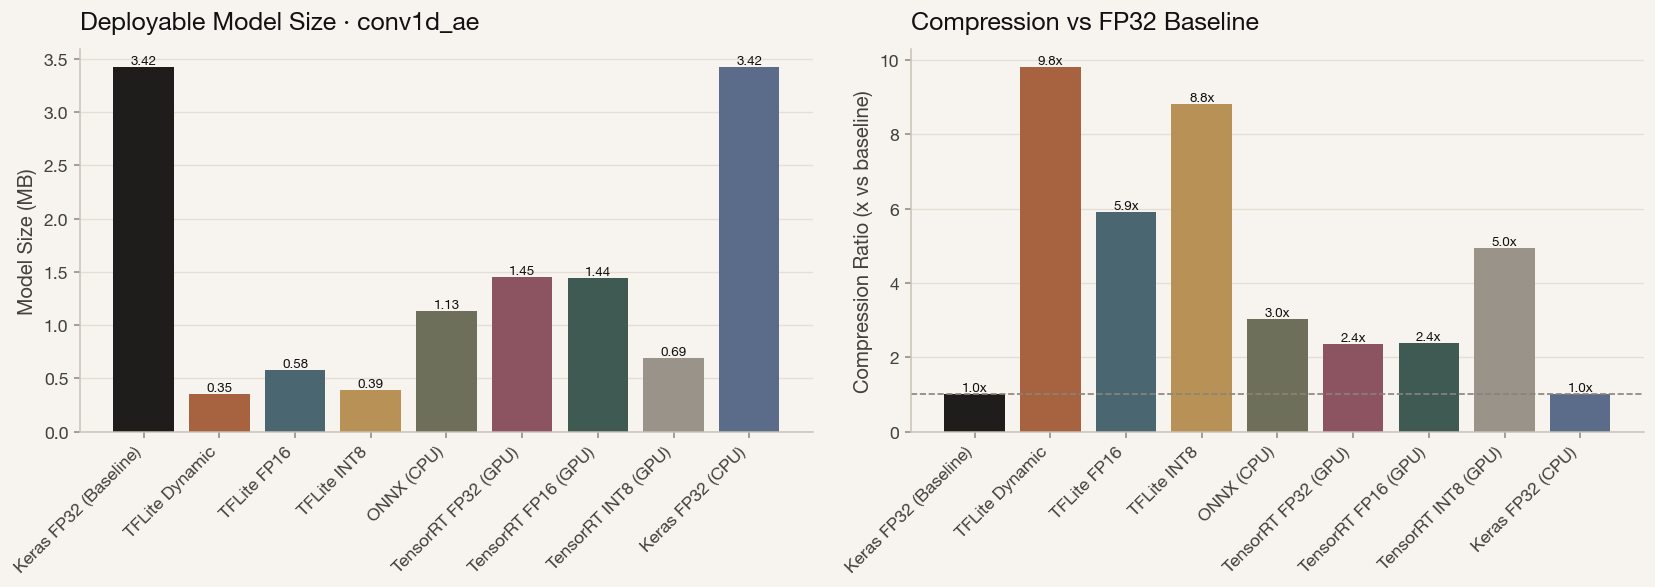

In [14]:
if evaluation_report:
    df = pd.DataFrame(evaluation_report)
    df = df.dropna(subset=["size_mb"]).drop_duplicates(subset=["model_name"])
    baseline_size = df.loc[df["model_name"].str.contains("Baseline"), "size_mb"]
    baseline_size = baseline_size.iloc[0] if len(baseline_size) else df["size_mb"].max()
    df["compression"] = baseline_size / df["size_mb"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    colors = [color_for(n) for n in df["model_name"]]

    ax1.bar(df["model_name"], df["size_mb"], color=colors)
    ax1.set_ylabel("Model Size (MB)")
    ax1.set_title(f"Deployable Model Size \u00b7 {MODEL}")
    ax1.tick_params(axis="x", rotation=45)
    for i, v in enumerate(df["size_mb"]):
        ax1.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8, color=INK)
    style_axis(ax1)

    ax2.bar(df["model_name"], df["compression"], color=colors)
    ax2.axhline(1.0, color=MUTED, ls="--", lw=1)
    ax2.set_ylabel("Compression Ratio (x vs baseline)")
    ax2.set_title("Compression vs FP32 Baseline")
    ax2.tick_params(axis="x", rotation=45)
    for i, v in enumerate(df["compression"]):
        ax2.text(i, v, f"{v:.1f}x", ha="center", va="bottom", fontsize=8, color=INK)
    style_axis(ax2)

    plt.setp(ax1.get_xticklabels(), ha="right")
    plt.setp(ax2.get_xticklabels(), ha="right")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_model_size_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")


## 2. Timing & Memory (Single-Sample, n=1)
Study 1: single-sample inference latency alongside the real memory footprint of each export format. CPU RAM is the process RSS delta and GPU VRAM is measured via NVML before/after execution, so both reflect the actual memory a model consumes. Every backend is timed under the same protocol — n=1, 15 warm-up iterations, 150 timed runs.


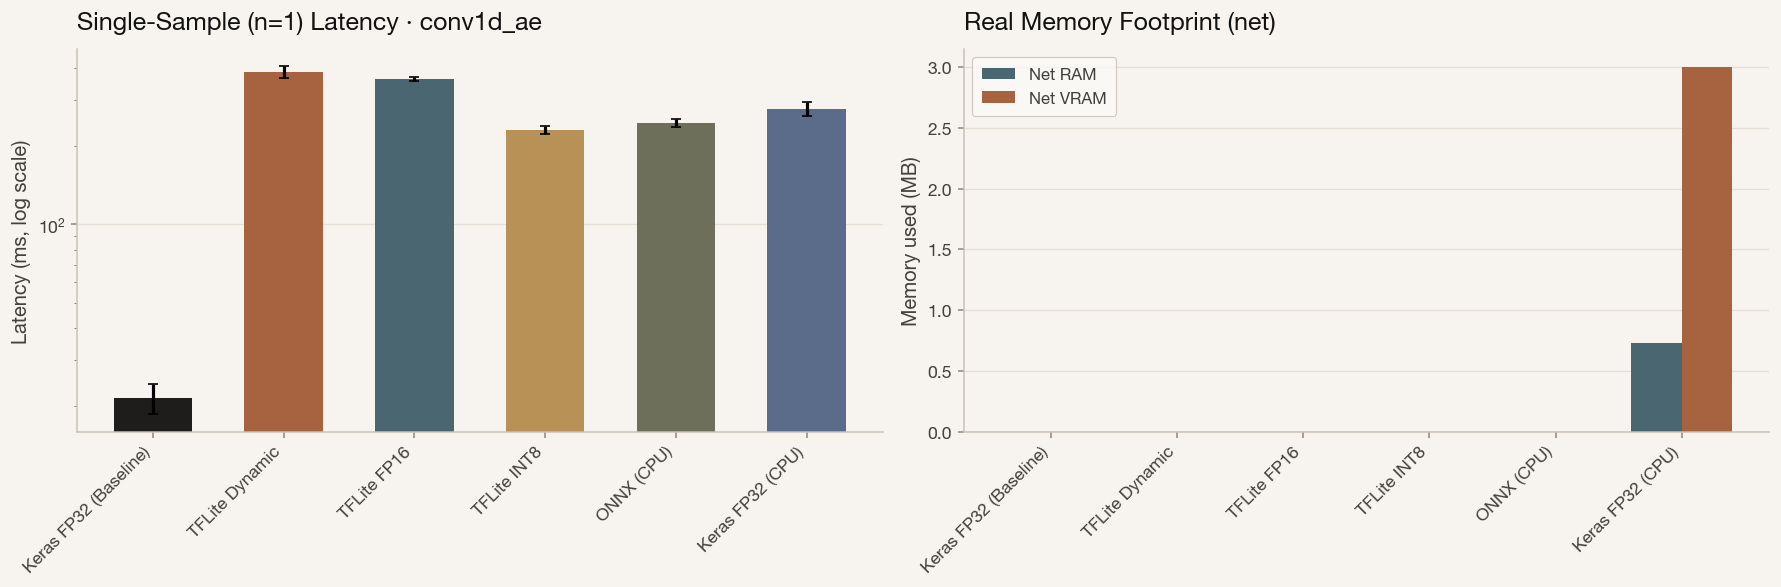

In [27]:
if performance_report:
    df = pd.DataFrame(performance_report).drop_duplicates(subset=["model_name"])
    names = df["model_name"].tolist()
    x = np.arange(len(names))
    colors = [color_for(n) for n in names]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Latency (single-sample, n=1)
    ax1.bar(x, df["latency_mean_ms"], 0.6, yerr=df["latency_std_ms"], capsize=3, color=colors)
    ax1.set_yscale("log")
    ax1.set_ylabel("Latency (ms, log scale)")
    ax1.set_title(f"Single-Sample (n=1) Latency \u00b7 {MODEL}")
    ax1.set_xticks(x)
    ax1.set_xticklabels(names, rotation=45, ha="right")
    style_axis(ax1)

    # Memory footprint: net RAM and net VRAM (before/after execution)
    w = 0.4
    ax2.bar(x - w / 2, df["net_ram_mb"], w, label="Net RAM", color=CATEGORICAL[2])
    ax2.bar(x + w / 2, df["net_vram_mb"], w, label="Net VRAM", color=ACCENT)
    ax2.set_ylabel("Memory used (MB)")
    ax2.set_title("Real Memory Footprint (net)")
    ax2.set_xticks(x)
    ax2.set_xticklabels(names, rotation=45, ha="right")
    ax2.legend()
    style_axis(ax2)

    plt.setp(ax1.get_xticklabels(), ha="right")
    plt.setp(ax2.get_xticklabels(), ha="right")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_timing_memory_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No performance (timing & memory) data available.")


## 3. Classification Fidelity Degradation
How each optimized format affects downstream anomaly-detection quality. Aggressive quantization can keep latency low while silently destroying AUC-ROC / accuracy — this chart surfaces those regressions.

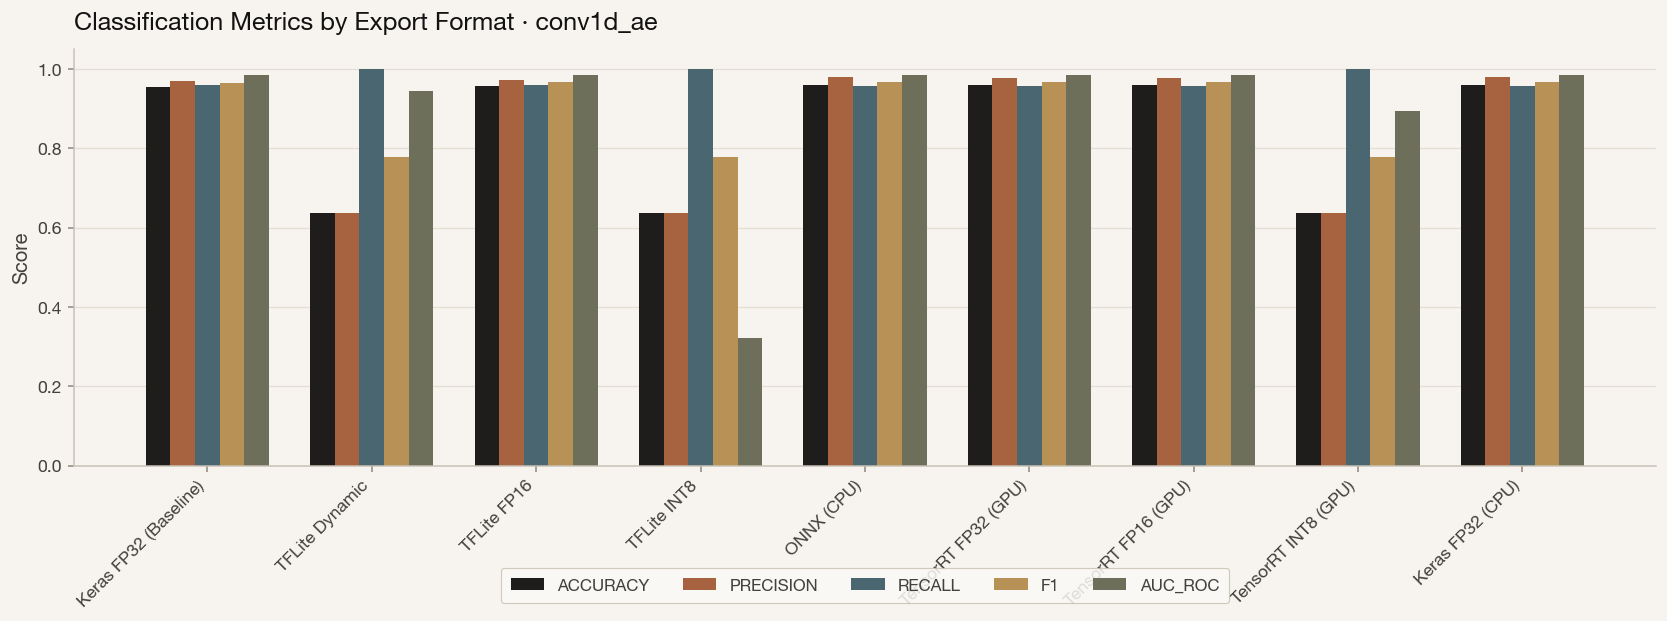

In [16]:
if evaluation_report:
    df = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    metrics = ["accuracy", "precision", "recall", "f1", "auc_roc"]
    names = df["model_name"].tolist()

    x = np.arange(len(names))
    w = 0.15
    fig, ax = plt.subplots(figsize=(14, 5.5))
    metric_colors = categorical_colors(len(metrics))
    for i, m in enumerate(metrics):
        offset = (i - (len(metrics) - 1) / 2) * w
        ax.bar(x + offset, df[m], w, label=m.upper(), color=metric_colors[i])
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Classification Metrics by Export Format \u00b7 {MODEL}")
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.legend(ncol=5, loc="lower center", bbox_to_anchor=(0.5, -0.35))
    style_axis(ax)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_metrics_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")


## 4. Inference Time per Sample
Per-sample inference time (seconds, from the metrics-study per-sample latency) for every export format, **including the batch-1 TensorRT engines**. Kernel fusion lets TensorRT run an order of magnitude faster while host formats stay dispatch-bound. Peak RAM/VRAM per format is reported in the summary table instead.


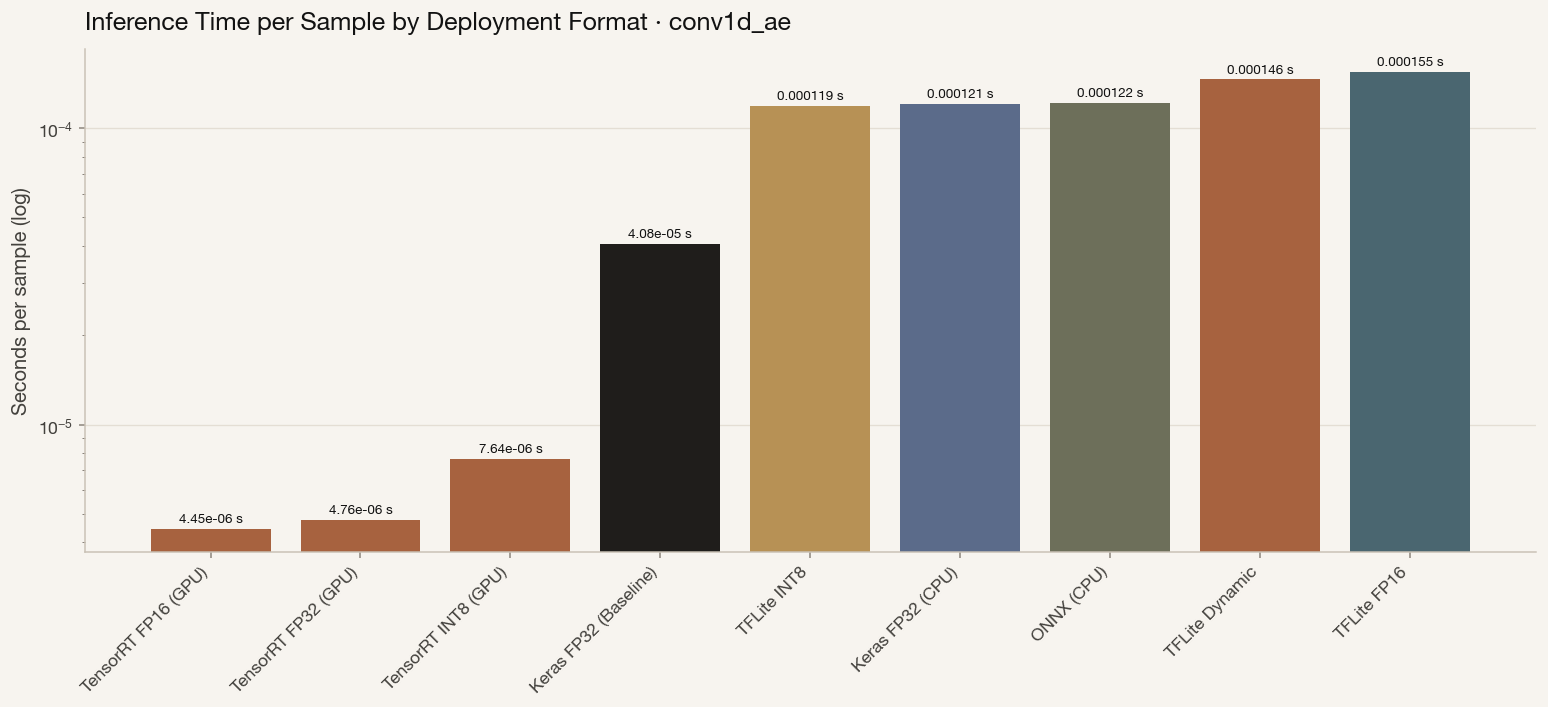

In [22]:
if evaluation_report:
    # Per-sample inference time (seconds) from the per-sample evaluation latency —
    # the one metric measured consistently across EVERY export format, including
    # the batch-1 TensorRT engines that have no in-process performance profile
    # (perf=None) and were therefore missing from the old latency/memory panel.
    df = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    df = df.dropna(subset=["latency_per_sample_mean_ms"])
    df = df[df["latency_per_sample_mean_ms"] > 0].copy()
    df["sec_per_sample"] = df["latency_per_sample_mean_ms"] / 1000.0
    df = df.sort_values("sec_per_sample", ascending=True)

    names = df["model_name"].tolist()
    spp = df["sec_per_sample"].to_numpy()
    # Group the TensorRT engines under the accent colour to foreground the
    # kernel-fusion win; every other format keeps its consistent deck colour.
    colors = [ACCENT if "TensorRT" in n else color_for(n) for n in names]

    fig, ax = plt.subplots(figsize=(13, 6))
    bars = ax.bar(names, spp, color=colors)
    ax.set_yscale("log")
    ax.set_ylabel("Seconds per sample (log)")
    ax.set_title(f"Inference Time per Sample by Deployment Format \u00b7 {MODEL}")
    ax.tick_params(axis="x", rotation=45)
    plt.setp(ax.get_xticklabels(), ha="right")
    for b, t in zip(bars, spp):
        ax.annotate(
            f"{t:.3g} s",
            (b.get_x() + b.get_width() / 2, t),
            textcoords="offset points",
            xytext=(0, 4),
            ha="center",
            fontsize=8,
            color=INK,
        )
    style_axis(ax)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_hardware_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")


## 5. Size / Latency / Accuracy Trade-off
A single Pareto-style view: each format positioned by model size (x) and per-sample latency (y), coloured by accuracy. The bottom-left, brightest points are the best deployment candidates.


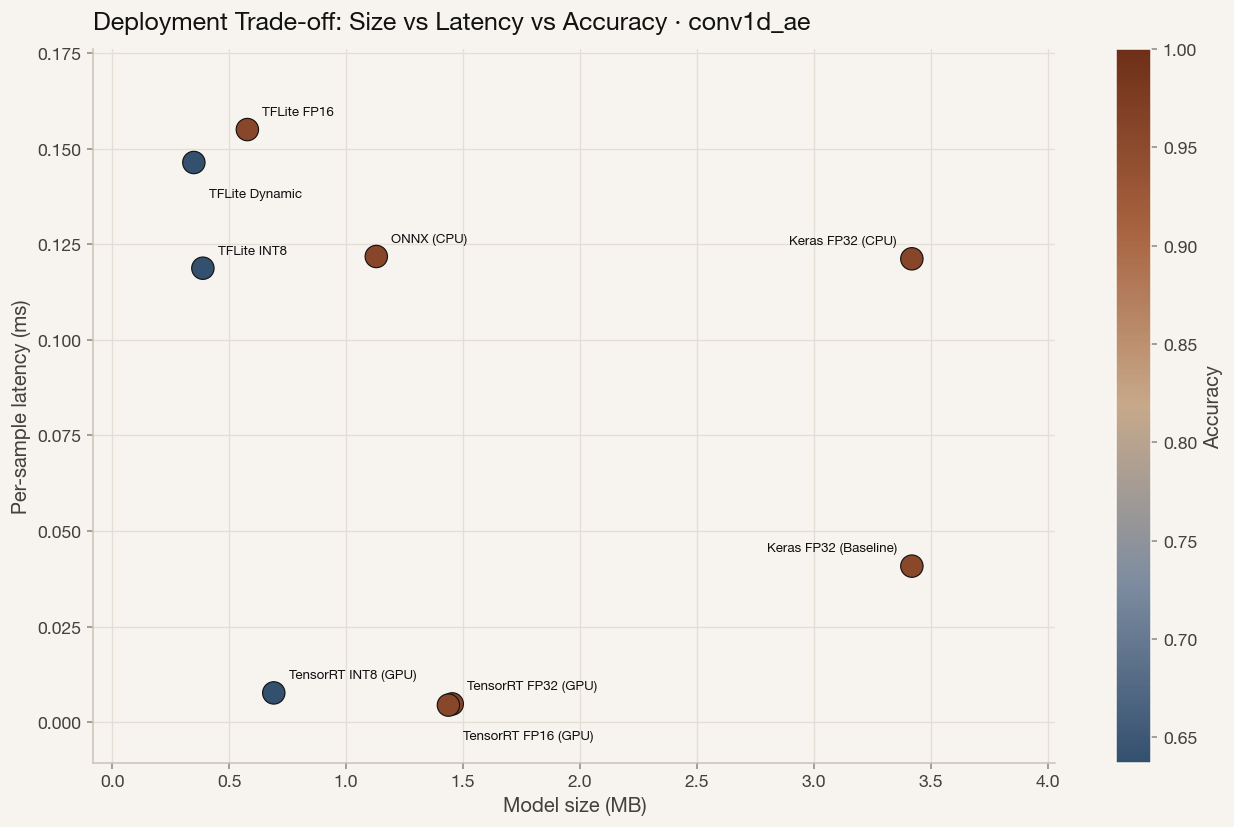

In [25]:
if evaluation_report:
    df = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    df = df.dropna(subset=["size_mb", "latency_per_sample_mean_ms", "accuracy"])

    fig, ax = plt.subplots(figsize=(11, 7))
    sc = ax.scatter(
        df["size_mb"],
        df["latency_per_sample_mean_ms"],
        c=df["accuracy"],
        s=180,
        cmap=SEQUENTIAL_CMAP,
        edgecolors=INK,
        linewidths=0.7,
        vmin=df["accuracy"].min(),
        vmax=1.0,
    )

    # Axis padding so annotations never spill outside the plotting area.
    xmin, xmax = df["size_mb"].min(), df["size_mb"].max()
    ymin, ymax = df["latency_per_sample_mean_ms"].min(), df["latency_per_sample_mean_ms"].max()
    xr = (xmax - xmin) or 1.0
    yr = (ymax - ymin) or 1.0
    ax.set_xlim(xmin - 0.14 * xr, xmax + 0.20 * xr)
    ax.set_ylim(ymin - 0.10 * yr, ymax + 0.14 * yr)

    # Right-side points get left-anchored labels; nearby points are staggered
    # vertically so their (wide) text boxes never overlap. Process from the top
    # down so the higher point keeps its label above and the lower one below.
    x_mid = xmin + 0.60 * xr
    placed = []
    for _, row in df.sort_values(
        ["latency_per_sample_mean_ms", "size_mb"], ascending=[False, True]
    ).iterrows():
        x, y, name = row["size_mb"], row["latency_per_sample_mean_ms"], row["model_name"]
        ha = "right" if x > x_mid else "left"
        dx = -9 if ha == "right" else 9
        dy = 7
        close = [p for p in placed if abs(p[0] - x) < 0.20 * xr and abs(p[1] - y) < 0.11 * yr]
        if close:
            dy = -15
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(dx, dy),
            fontsize=8,
            color=INK,
            ha=ha,
            va="top" if dy < 0 else "bottom",
        )
        placed.append((x, y))

    ax.set_xlabel("Model size (MB)")
    ax.set_ylabel("Per-sample latency (ms)")
    ax.set_title(f"Deployment Trade-off: Size vs Latency vs Accuracy \u00b7 {MODEL}")
    ax.grid(True, axis="both")
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("Accuracy")
    cbar.outline.set_edgecolor(PAPER_SOFT)
    style_axis(ax)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"deploy_tradeoff_{MODEL}.png", bbox_inches="tight")
    plt.show()
else:
    print("No evaluation_benchmark_report.json available.")


## 6. Summary Table
Consolidated per-format view combining size, latency, and classification metrics for quick reference.


In [11]:
if evaluation_report:
    summary = pd.DataFrame(evaluation_report).drop_duplicates(subset=["model_name"])
    cols = [
        "model_name",
        "size_mb",
        "latency_per_sample_mean_ms",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "auc_roc",
    ]
    summary = summary[[c for c in cols if c in summary.columns]].round(4)
    display(summary.reset_index(drop=True))
else:
    print("No evaluation_benchmark_report.json available.")

,model_name,size_mb,latency_per_sample_mean_ms,accuracy,precision,recall,f1,auc_roc
0,Keras FP32 (Baseline),3.4198,0.0408,0.9555,0.9702,0.9597,0.9649,0.9851
1,TFLite Dynamic,0.3490,0.1464,0.6371,0.6371,1.0000,0.7783,0.9446
2,TFLite FP16,0.5778,0.1550,0.9576,0.9731,0.9599,0.9665,0.9854
3,TFLite INT8,0.3876,0.1188,0.6371,0.6371,1.0000,0.7783,0.3213
4,ONNX (CPU),1.1292,0.1218,0.9600,0.9801,0.9568,0.9683,0.9861
5,TensorRT FP32 (GPU),1.4540,0.0048,0.9590,0.9784,0.9568,0.9675,0.9854
6,TensorRT FP16 (GPU),1.4377,0.0044,0.9588,0.9780,0.9569,0.9673,0.9852
7,TensorRT INT8 (GPU),0.6908,0.0076,0.6371,0.6371,1.0000,0.7783,0.8946
8,Keras FP32 (CPU),3.4198,0.1212,0.9600,0.9800,0.9567,0.9682,0.9861
